# Detecting expr1.fsize plot

简洁版 detecting 绘图入口。只改下面 `RUN_ROOT`，然后顺序运行即可。


In [1]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# RUN_ROOT = Path.home() / "code/data/20260601/cgnr6760pn2/outputDetecting/20260601-181757"
# RUN_ROOT = Path.home() / "code/data/20260601/cgnr6760pn2/outputDetecting/20260601-174851"
# RUN_ROOT = Path.home() / "code/data/20260601/cgnr6760pn2/outputDetecting/20260601-173655"
# RUN_ROOT = Path.home() / "code/data/20260601/cgnr6760pn2/outputDetecting/20260601-163606"
RUN_ROOT = Path.home() / "code/data/20260601/cgnr6760pn2/outputDetecting/20260601-153139"


REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "scripts":
    REPO_ROOT = REPO_ROOT.parent
OUT_DIR = REPO_ROOT / "scripts_plot/outputDetecting"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RL_RH_NQUANT = 1000
RL_RH_DELTA = 5
RL_RH_Q = 900

TIMER_COLORS = {
    "tsc": "tab:blue",
    "tsc_asym": "tab:cyan",
    "clock_gettime": "tab:orange",
    "mpi_wtime": "tab:green",
    "papi": "tab:red",
    "papix6": "tab:purple",
    "likwid": "tab:brown",
    "cntvct": "tab:cyan",
    "cntvct_fence": "tab:olive",
    "cntvcto": "tab:pink",
}

print(RUN_ROOT)


/astrum/home/hpchzy/code/data/20260601/cgnr6760pn2/outputDetecting/20260601-153139


In [2]:
def parse_meta(path):
    d = {}
    if not path.exists():
        return d
    for line in path.read_text(errors="ignore").splitlines():
        if "=" in line:
            k, v = line.split("=", 1)
            d[k.strip()] = v.strip()
    return d


def read_values(path):
    vals = []
    for line in path.read_text(errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        try:
            vals.append(float(line.split(",")[-1]))
        except ValueError:
            pass
    return vals


def q(vals, p):
    vals = sorted(vals)
    if not vals:
        return math.nan
    if len(vals) == 1:
        return vals[0]
    pos = p * (len(vals) - 1)
    lo, hi = math.floor(pos), math.ceil(pos)
    if lo == hi:
        return vals[lo]
    return vals[lo] * (hi - pos) + vals[hi] * (pos - lo)


def empirical_w1(a, b):
    if not a or not b:
        return math.nan
    n = max(len(a), len(b))
    if n == 1:
        return abs(a[0] - b[0])
    return sum(abs(q(a, i / (n - 1)) - q(b, i / (n - 1))) for i in range(n)) / n


def local_w_hat(theory, measured, x_idx, y_idx):
    theory, measured = sorted(theory), sorted(measured)
    if not theory or not measured or x_idx > y_idx:
        return math.nan
    tau = measured[0] - theory[0]
    vals = []
    for idx in range(x_idx, y_idx + 1):
        p = (idx - 1) / (RL_RH_NQUANT - 1)
        vals.append(abs(q(measured, p) - q(theory, p) - tau))
    return float(np.mean(vals)) if vals else math.nan


def theory_w_hat(theory, x_idx, y_idx):
    theory = sorted(theory)
    if not theory or x_idx > y_idx:
        return math.nan
    tmin = theory[0]
    vals = []
    for idx in range(x_idx, y_idx + 1):
        p = (idx - 1) / (RL_RH_NQUANT - 1)
        vals.append(abs(q(theory, p) - tmin))
    return float(np.mean(vals)) if vals else math.nan


def rl_rh_detail(measured, theory):
    low_num = local_w_hat(theory, measured, 1, RL_RH_Q)
    low_den = theory_w_hat(theory, 1, RL_RH_Q)
    high_num = local_w_hat(theory, measured, RL_RH_Q + 1, RL_RH_NQUANT - RL_RH_DELTA)
    high_den = theory_w_hat(theory, RL_RH_Q + 1, RL_RH_NQUANT - RL_RH_DELTA)
    rl = low_num / low_den * 100 if low_den and np.isfinite(low_den) else math.nan
    rh = high_num / high_den * 100 if high_den and np.isfinite(high_den) else math.nan
    return rl, rh, low_num, low_den, high_num, high_den


def ta_from_run_dir(run_dir, meta):
    m = re.search(r"_ta([0-9.]+)", run_dir.name)
    if m:
        return float(m.group(1))
    return float(meta.get("interval_ns", 0) or 0)


In [3]:
rows = []
for cdf in sorted(RUN_ROOT.rglob("*_ta_cdf.csv")):
    run_dir = cdf.parent
    combo_dir = run_dir.parent
    meta = parse_meta(combo_dir / "meta.txt")
    measured = read_values(cdf)
    if not measured:
        continue
    ta = ta_from_run_dir(run_dir, meta)
    rows.append({
        "host": meta.get("host", RUN_ROOT.parts[-3] if len(RUN_ROOT.parts) >= 3 else ""),
        "expr": meta.get("expr_name", RUN_ROOT.name),
        "np": int(meta.get("np", 0) or 0),
        "timer": meta.get("timer", cdf.parents[2].name),
        "interval_ns": int(float(meta.get("interval_ns", 0) or 0)),
        "fsize_kib": int(float(meta.get("fsize_kib", 0) or 0)),
        "fkern": meta.get("fkern", ""),
        "rkern": meta.get("rkern", ""),
        "ta": ta,
        "n_measured": len(measured),
        "measured": measured,
        "theory": [ta] * len(measured),
        "run_dir": str(run_dir),
    })

raw = pd.DataFrame(rows)
print(f"cdf files: {len(raw)}")
raw = raw[raw["interval_ns"] == 10000]
raw.head()


cdf files: 70


,host,expr,np,timer,interval_ns,fsize_kib,fkern,rkern,ta,n_measured,measured,theory,run_dir
0,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,1024,copy,none,1000.0,100,"[1036.0, 1039.0, 1039.0, 1039.0, 1040.0, 1040....","[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....",/astrum/home/hpchzy/code/data/20260601/cgnr676...
1,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,128,copy,none,1000.0,100,"[1035.0, 1039.0, 1039.0, 1040.0, 1040.0, 1040....","[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....",/astrum/home/hpchzy/code/data/20260601/cgnr676...
2,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,16,copy,none,1000.0,100,"[1035.0, 1038.0, 1038.0, 1039.0, 1039.0, 1039....","[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....",/astrum/home/hpchzy/code/data/20260601/cgnr676...
3,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,2048,copy,none,1000.0,100,"[1035.0, 1038.0, 1039.0, 1039.0, 1039.0, 1040....","[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....",/astrum/home/hpchzy/code/data/20260601/cgnr676...
4,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,256,copy,none,1000.0,100,"[1034.0, 1039.0, 1039.0, 1039.0, 1040.0, 1040....","[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....",/astrum/home/hpchzy/code/data/20260601/cgnr676...


In [4]:
summary_rows = []
keys = ["host", "expr", "np", "timer", "interval_ns", "fsize_kib", "fkern", "rkern"]
for key, g in raw.groupby(keys, dropna=False):
    measured = [x for vals in g["measured"] for x in vals]
    theory = [x for vals in g["theory"] for x in vals]
    rl, rh, low_num, low_den, high_num, high_den = rl_rh_detail(measured, theory)
    row = dict(zip(keys, key))
    row.update({
        "n_walks": len(g),
        "n_measured": len(measured),
        "theory_min": min(theory) if theory else math.nan,
        "theory_max": max(theory) if theory else math.nan,
        "measured_mean": float(np.mean(measured)) if measured else math.nan,
        "w1_ns": empirical_w1(measured, theory),
        "rl_pct": rl,
        "rh_pct": rh,
        "low_num": low_num,
        "low_den": low_den,
        "high_num": high_num,
        "high_den": high_den,
    })
    summary_rows.append(row)

df = pd.DataFrame(summary_rows).sort_values(["np", "timer", "fsize_kib"]).reset_index(drop=True)
print(df[["timer", "fsize_kib", "n_walks", "w1_ns", "rl_pct", "rh_pct", "low_den", "high_den"]].to_string(index=False))
df.head()


        timer  fsize_kib  n_walks   w1_ns       rl_pct  rh_pct      low_den  high_den
clock_gettime         16        1   45.21 2.703071e+18     NaN 2.526374e-16       0.0
clock_gettime         32        1   95.92 2.664574e+18     NaN 2.526374e-16       0.0
clock_gettime         64        1   96.60 2.669044e+18     NaN 2.526374e-16       0.0
clock_gettime        128        1  140.83 3.089057e+18     NaN 2.526374e-16       0.0
clock_gettime        256        1  302.31 3.362580e+18     NaN 2.526374e-16       0.0
clock_gettime        512        1   97.02 3.349303e+18     NaN 2.526374e-16       0.0
clock_gettime       1024        1  184.97 2.649696e+18     NaN 2.526374e-16       0.0
clock_gettime       2048        1  329.42 1.050822e+19     NaN 2.526374e-16       0.0
clock_gettime       4096        1  491.49 3.429666e+19     NaN 2.526374e-16       0.0
clock_gettime       8192        1  150.40 1.206600e+19     NaN 2.526374e-16       0.0
       likwid         16        1 2121.66 3.000264e+18

,host,expr,np,timer,interval_ns,fsize_kib,fkern,rkern,n_walks,n_measured,theory_min,theory_max,measured_mean,w1_ns,rl_pct,rh_pct,low_num,low_den,high_num,high_den
0,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,16,copy,none,1,100,1000.0,1000.0,1045.21,45.21,2.703071e+18,NaN,6.828969,2.526374e-16,24.601328,0.0
1,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,32,copy,none,1,100,1000.0,1000.0,1095.92,95.92,2.664574e+18,NaN,6.731712,2.526374e-16,102.033286,0.0
2,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,64,copy,none,1,100,1000.0,1000.0,1096.60,96.60,2.669044e+18,NaN,6.743003,2.526374e-16,101.061546,0.0
3,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,128,copy,none,1,100,1000.0,1000.0,1140.83,140.83,3.089057e+18,NaN,7.804114,2.526374e-16,175.264770,0.0
4,cgnr6760pn2,detecting.expr1.fsize,64,clock_gettime,10000,256,copy,none,1,100,1000.0,1000.0,1302.31,302.31,3.362580e+18,NaN,8.495135,2.526374e-16,440.109151,0.0


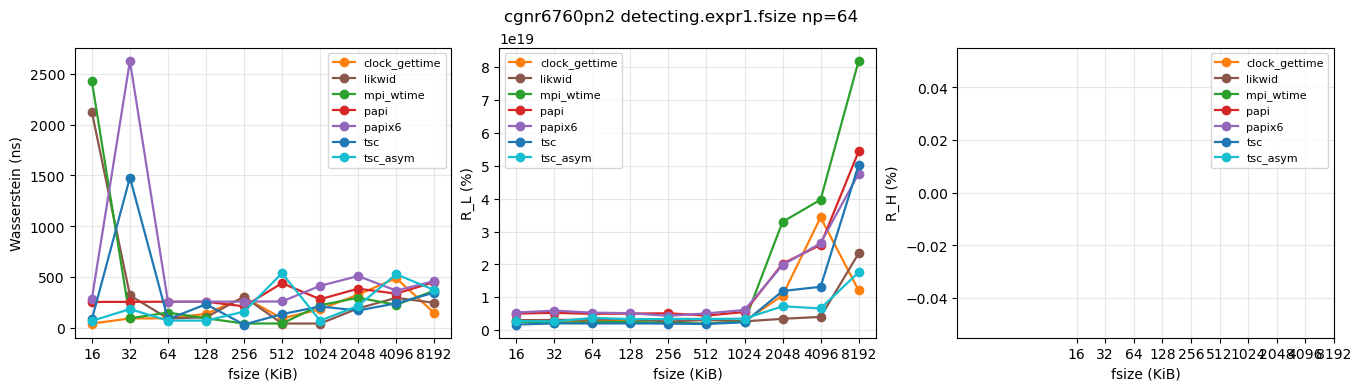

/astrum/home/hpchzy/code/TacVar/scripts_plot/outputDetecting/detecting_expr1_fsize_20260601_cgnr6760pn2.png


In [5]:
# Plot W1, R_L, R_H vs fsize.  If R_L/R_H is blank, check low_den/high_den above.
plot_df = df.copy()
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
metrics = [("w1_ns", "Wasserstein (ns)"), ("rl_pct", "R_L (%)"), ("rh_pct", "R_H (%)")]

for ax, (metric, ylabel) in zip(axes, metrics):
    for timer, g in plot_df.groupby("timer"):
        g = g.sort_values("fsize_kib")
        color = TIMER_COLORS.get(timer, None)
        ax.plot(g["fsize_kib"], g[metric], marker="o", linewidth=1.6, label=timer, color=color)
    ax.set_xscale("log", base=2)
    ax.set_xticks(sorted(plot_df["fsize_kib"].unique()))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xlabel("fsize (KiB)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

title = f"{plot_df['host'].iloc[0]} {plot_df['expr'].iloc[0]} np={plot_df['np'].iloc[0]}" if not plot_df.empty else "detecting expr1.fsize"
fig.suptitle(title)
fig_path = OUT_DIR / "detecting_expr1_fsize_20260601_cgnr6760pn2.png"
fig.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()
print(fig_path)


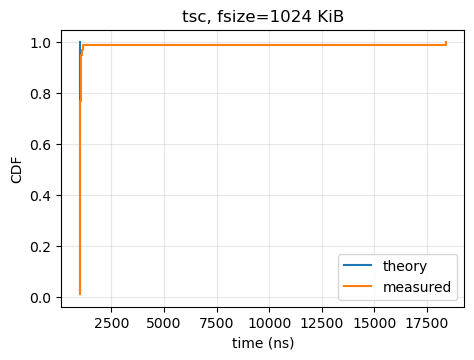